# Stitching Images (minimal example for small data)

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

import microscopy_data_analysis as mda

In [2]:
#for the next line to work, the file create_example_for_grid_stitching.py
#should be in the same directory as this notebook
import create_data_for_grid_stitching

create_data_for_grid_stitching.run_script()

In [3]:
# get filepaths to images
example_path="example_images"
pathlist=mda.get_files_of_format(example_path,"tif")
N=len(pathlist)
pathlist[:3]

['example_images/image_00.tif',
 'example_images/image_01.tif',
 'example_images/image_02.tif']

In [4]:
# load images into RAM (recommended only for small dataset)
img_list=[]
for imgpath in pathlist:
    img_list.append(cv2.imread(imgpath,0))
img_list[0].shape

(500, 500)

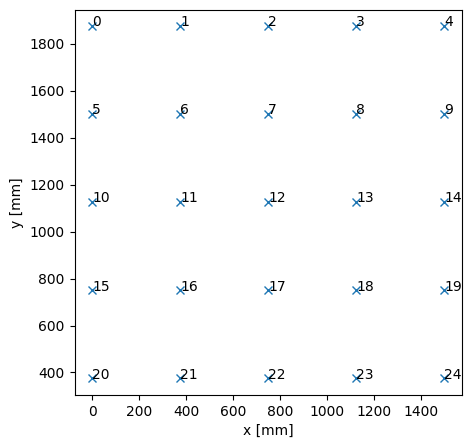

In [5]:
%matplotlib inline

# create and plot some estimated positions for stitching the images
positions=np.zeros([N,2])
counter=0
for i in range(5):
    for j in range(5):
        # assuming 25% overlap with an image width of 500 pixels, 
        # the next image should start after 375 pixels
        positions[counter]=j*375,5*375-i*375
        counter+=1

plt.figure(figsize=[5,5])
plt.plot(positions[:,0],positions[:,1],'x')
for i in range(len(positions)):
    plt.text(positions[i,0],positions[i,1],str(i))
plt.xlabel(r"x [mm]")
plt.ylabel(r"y [mm]")
plt.axis("equal")
plt.show()

The mode 'memory' is only recommended for a small datasets as everything is stored in RAM. 
25 low resolution 500x500 images with low bit-depth uint8 would correspond to ~6.25Mb. 
Copies in float32 will be needed, inflating the data by a factor of 4, which still is tiny.

But for example 400 images with resolution 2048x2048 in float32 would take ~6.25Gb of RAM.
In that case (see other example), considering that also copies are needed for processing, 
the mode 'storage' is recommended (assuming ~16Gb of RAM).  

Rule of thumb: If the size of all images in float32 times 4 is smaller than the amount of RAM, 
then the mode "memory" is fine.

In [6]:
stack=mda.image_stack(mode='memory')

please provide the images, as a list of images via 'set_img_list'


In [7]:
stack.set_img_list(img_list)

In [8]:
stack.sniff_dimensions()
# check values
stack.dimensions[:3]

array([[500, 500],
       [500, 500],
       [500, 500]])

In [9]:
# since our estimated position are given in pixels,
# the correct value would be 1, 
# but let's assume the value is not precise
stack.set_units_per_pixel(1.1)

In [10]:
stack.set_positions(positions)
polygons,anchor_points=stack.make_polygons()

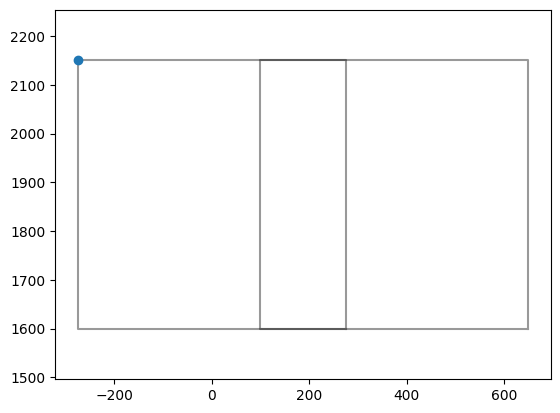

In [11]:
%matplotlib inline

# check for two images, if there is overlap
# also origin (anchor) of the pixel coordinates, shown as blue dot, should be 
# in the left upper corner of an image

index=0
plt.plot(np.array(polygons[index].exterior.xy[0]),np.array(polygons[index].exterior.xy[1]),'k-',alpha=0.4)
plt.plot(anchor_points[index][0],anchor_points[index][1],'o')
index=1
plt.plot(np.array(polygons[index].exterior.xy[0]),np.array(polygons[index].exterior.xy[1]),'k-',alpha=0.4)
plt.axis("equal")
plt.show()

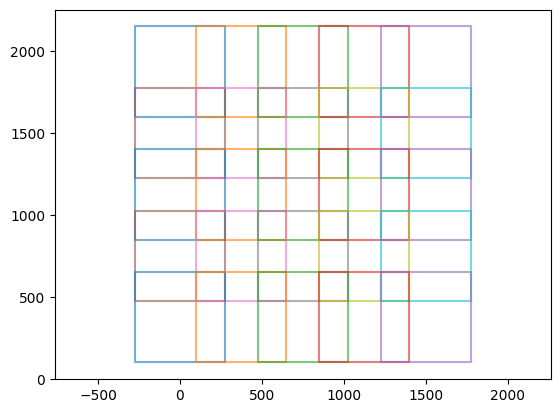

In [12]:
# show all images (abstracted as polygons)
for index in range(len(stack.polygons)):
    plt.plot(np.array(stack.polygons[index].exterior.xy[0]),np.array(stack.polygons[index].exterior.xy[1]),'-',alpha=0.6)
plt.axis("equal")
plt.show()

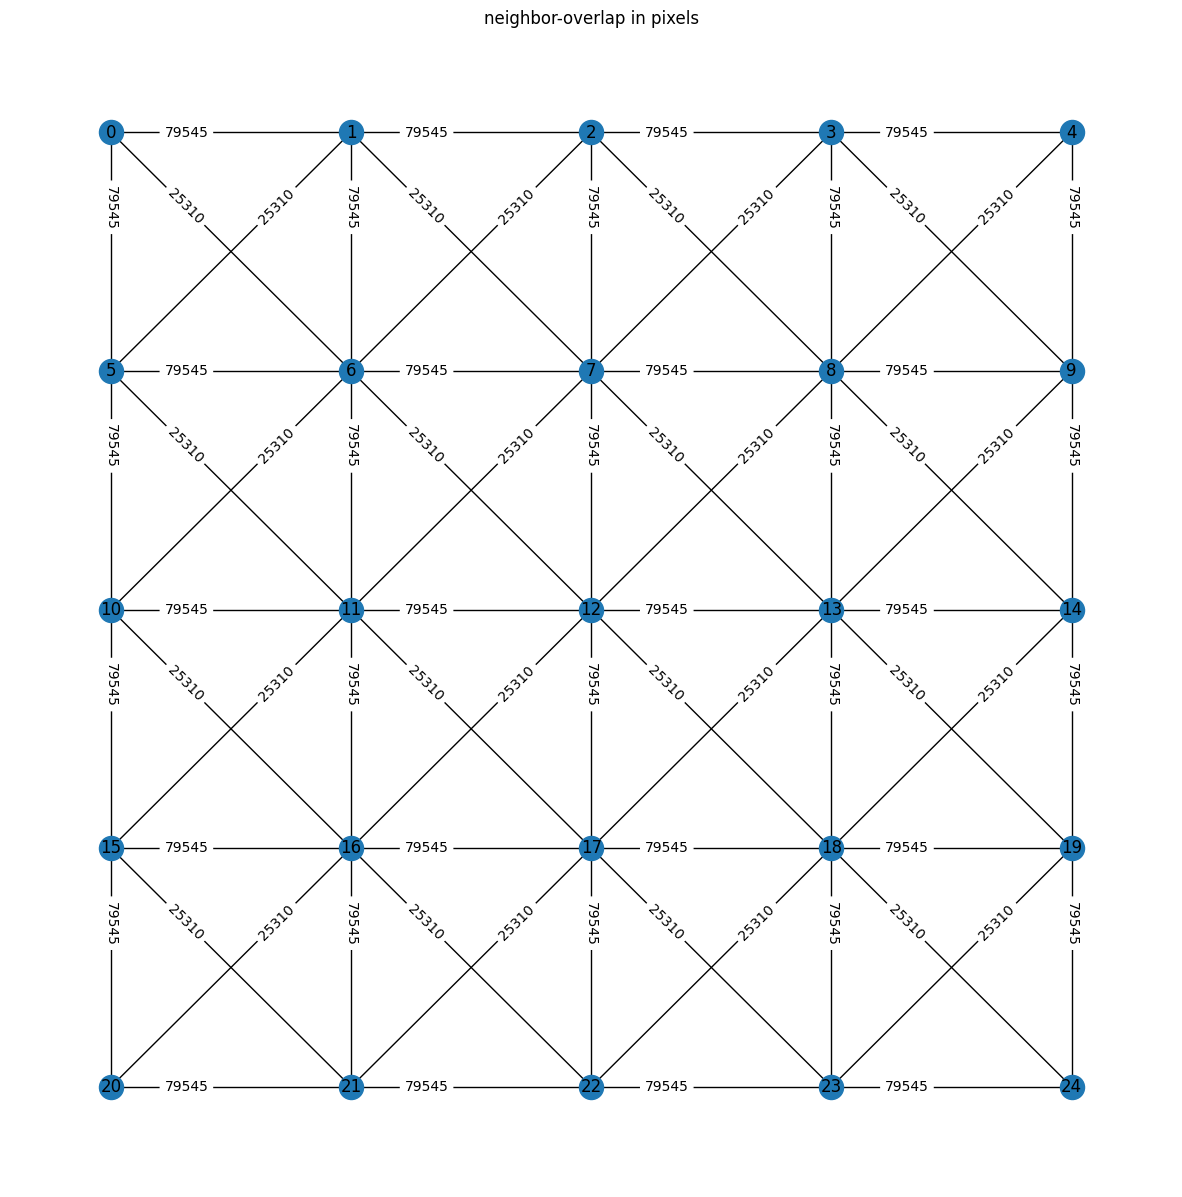

In [13]:
connected_groups=stack.connection_groups()
stack.plot_connection_network(figsize=[15,15],relative=False)

In [14]:
pair_shifts=stack.check_pairs()

100%|██████████| 72/72 [00:03<00:00, 19.89it/s]


In [15]:
moved_polygons=stack.optimize_positions()

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.0092e+05                                    2.00e+02    
       1              3         5.2491e+04      4.84e+04       1.71e+02       1.04e+02    
       2              5         4.0763e+04      1.17e+04       8.56e+01       4.60e+01    
       3              6         3.6472e+04      4.29e+03       8.56e+01       1.08e+02    
       4              7         3.6394e+04      7.70e+01       8.56e+01       8.52e+01    
       5              8         3.2557e+04      3.84e+03       2.14e+01       5.04e+01    
       6              9         3.1175e+04      1.38e+03       4.28e+01       4.34e+01    
       7             11         3.0381e+04      7.93e+02       1.07e+01       1.97e+01    
       8             12         2.9967e+04      4.15e+02       2.14e+01       1.87e+01    
       9             13         2.9817e+04      1.50e+02       2.14e+01       2.74e+01    

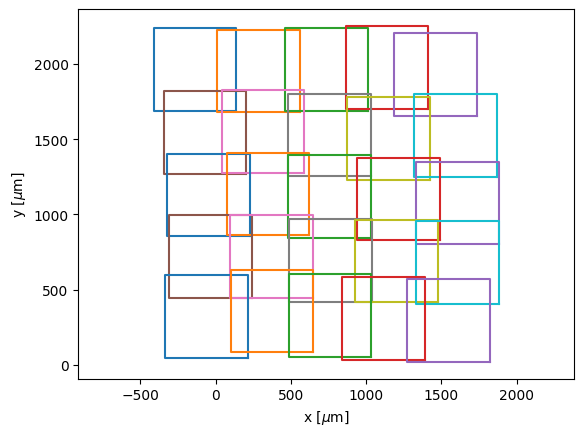

In [16]:
%matplotlib inline
for i in range(len(moved_polygons)):
    plt.plot(np.array(moved_polygons[i].exterior.xy[0]),np.array(moved_polygons[i].exterior.xy[1]))#'k-')
plt.xlabel(r"x [$\mu$m]")
plt.ylabel(r"y [$\mu$m]")
plt.axis("equal")
plt.show()

100%|██████████| 25/25 [00:00<00:00, 606.53it/s]


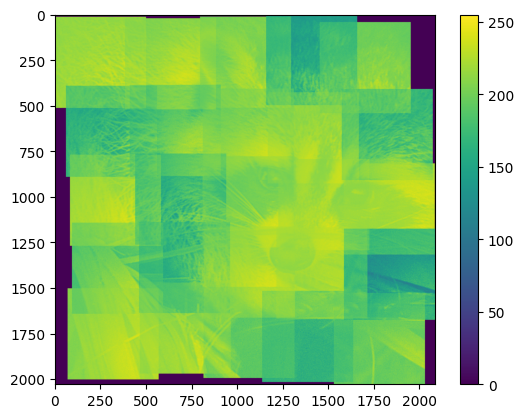

In [17]:
testmap=stack.map_from_polygons(moved_polygons,blending="average")
plt.imshow(testmap)
plt.colorbar()
plt.show()

### Optional: second iteration (start)

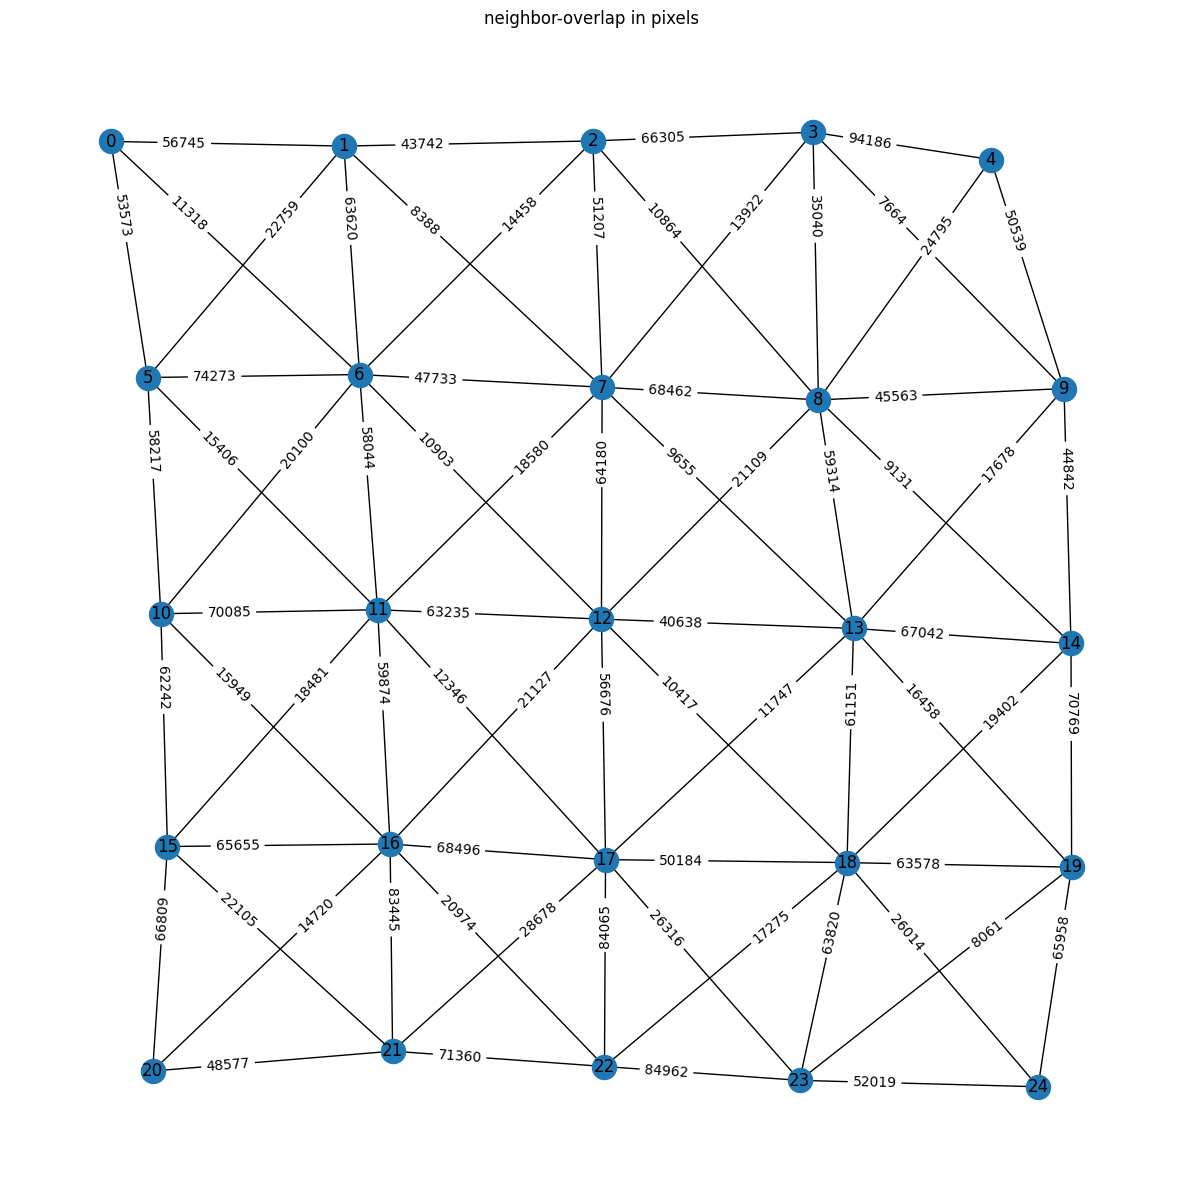

In [ ]:
# use the new positions of image tiles as starting estimate and repeat the process
# (does not always lead to a better result, but it's a quick second try, 
# if the first result is not good) 
stack.refine_positions(moved_polygons=moved_polygons)

In [19]:
pair_shifts=stack.check_pairs()

100%|██████████| 72/72 [00:02<00:00, 28.42it/s]


In [20]:
moved_polygons=stack.optimize_positions()

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.2608e+04                                    1.11e+02    
       1              3         2.1653e+04      2.10e+04       1.63e+02       5.34e+01    
       2              5         1.5310e+04      6.34e+03       6.94e+01       3.18e+01    
       3              6         1.3233e+04      2.08e+03       1.39e+02       5.20e+01    
       4              8         1.0921e+04      2.31e+03       3.47e+01       1.48e+01    
       5              9         1.0538e+04      3.83e+02       3.47e+01       1.44e+01    
       6             11         1.0369e+04      1.69e+02       8.67e+00       4.62e+00    
       7             12         1.0284e+04      8.49e+01       8.67e+00       2.95e+00    
       8             13         1.0169e+04      1.15e+02       1.73e+01       3.65e+00    
       9             15         1.0139e+04      3.04e+01       8.67e+00       4.02e+00    

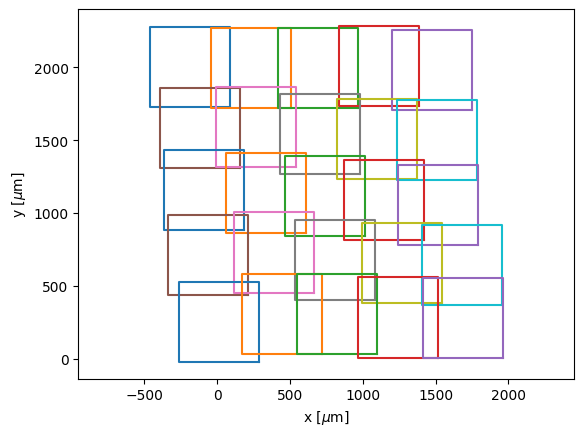

In [21]:
%matplotlib inline
for i in range(len(moved_polygons)):
    plt.plot(np.array(moved_polygons[i].exterior.xy[0]),np.array(moved_polygons[i].exterior.xy[1]))#'k-')
plt.xlabel(r"x [$\mu$m]")
plt.ylabel(r"y [$\mu$m]")
plt.axis("equal")
plt.show()

100%|██████████| 25/25 [00:00<00:00, 516.79it/s]


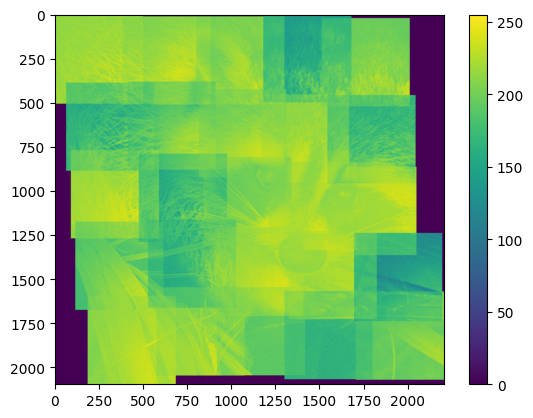

In [22]:
testmap=stack.map_from_polygons(moved_polygons,blending="average")
plt.imshow(testmap)
plt.colorbar()
plt.show()

### Optional: second iteration (end)

In [23]:
mda.imsave("stitching_example_small.png",testmap.astype(np.uint8))

(2096, 2206)


True